# EEG Motor İmgelem Sınıflandırması — v3
## PhysioNet EEG Motor Movement/Imagery Dataset

**Kaynak:** https://www.physionet.org/content/eegmmidb/1.0.0/

### v3 İyileştirmeleri
- **64 kanal** kullanımı (CSP yüksek boyutlu veride daha iyi çalışır)
- **Mu (8–12 Hz) + Beta (13–25 Hz)** ayrı ayrı filtreleme ve bant bazlı CSP
- **N_SUBJECTS = 40–50** denek (daha geniş varyasyon)
- **LOSO (Leave-One-Subject-Out)** çapraz doğrulama — veri sızıntısı tamamen engellendi
- **CSP + SVM pipeline** içinde tutarlı eğitim

## 1. Kütüphaneler

In [1]:
# !pip install mne scikit-learn numpy pandas matplotlib seaborn scipy

In [2]:
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import welch
from scipy.stats import kurtosis, skew

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneGroupOut, cross_validate
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from mne.decoding import CSP

mne.set_log_level('WARNING')
print(f"MNE: {mne.__version__}")
import sklearn; print(f"sklearn: {sklearn.__version__}")

MNE: 1.12.1
sklearn: 1.8.0


## 2. Parametreler

Üç önemli değişiklik:
- `N_SUBJECTS = 40` → daha fazla veri, modelin daha iyi genelleme yapmasını sağlar
- `USE_ALL_CHANNELS = True` → 64 kanal; CSP yüksek boyuttan faydalanır
- Mu ve Beta bantları **ayrı ayrı** filtrelenip CSP özelliği çıkarılacak

In [3]:
# ── Veri yolu ─────────────────────────────────────────────────
DATA_DIR = '../physioNet_Dataset'

# ── Tavsiye 3: Daha fazla denek ───────────────────────────────
N_SUBJECTS   = 40          # 40-50 arası önerilir; artırdıkça süre de artar
IMAGERY_RUNS = ['R04', 'R08', 'R12']

# ── Tavsiye 1: Tüm kanalları kullan ──────────────────────────
USE_ALL_CHANNELS = True    # False yaparsanız sadece motor korteks kanalları
MOTOR_CHANNELS   = ['C3', 'CZ', 'C4', 'FC3', 'FC4', 'CP3', 'CP4',
                    'FC1', 'FC2', 'C1', 'C2', 'CP1', 'CP2']

# ── Tavsiye 2: Bant odaklı filtreleme ─────────────────────────
# Mu ve Beta ayrı filtrelenip her birinden ayrı CSP çıkarılacak
BANDS = {
    'mu'  : (8.0, 12.0),   # Mu ritmi — motor korteks desenkronizasyonu
    'beta': (13.0, 25.0),  # Beta ritmi — motor hazırlık ve imgelem
}

TMIN, TMAX         = 1.0, 4.0   # Saf imgelem penceresi (uyarı gecikmesi atlandı)
N_CSP_COMPONENTS   = 8          # Her bant için 8 bileşen (4+4)
N_SUBJECTS_LOADED  = 0          # Yükleme sonrası güncellenir

print(f"Denek sayısı  : {N_SUBJECTS}")
print(f"Kanal modu    : {'Tüm kanallar (64)' if USE_ALL_CHANNELS else 'Motor kanallar'}")
print(f"Bantlar       : {list(BANDS.keys())}")
print(f"Epoch         : {TMIN}-{TMAX}s  |  CSP bileşen/bant: {N_CSP_COMPONENTS}")

Denek sayısı  : 40
Kanal modu    : Tüm kanallar (64)
Bantlar       : ['mu', 'beta']
Epoch         : 1.0-4.0s  |  CSP bileşen/bant: 8


## 3. Veri Yükleme ve Ön İşleme

In [4]:
def load_subject(subject_id, runs, data_dir, band_freqs, use_all_ch, motor_chs):
    """
    Bir denek için her bant ayrı filtrelenmiş epoch döndürür.
    Dönüş: {band_name: mne.Epochs}
    """
    sub = f'S{subject_id:03d}'
    raws = []
    for run in runs:
        path = f'{data_dir}/{sub}/{sub}{run}.edf'
        try:
            raws.append(mne.io.read_raw_edf(path, preload=True, verbose=False))
        except FileNotFoundError:
            pass
    if not raws:
        return None

    raw = mne.concatenate_raws(raws)

    # Kanal isimlerini normalize et
    raw.rename_channels({ch: ch.rstrip('.').upper() for ch in raw.ch_names})
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore')
    raw.pick('eeg')

    # Kanal seçimi
    if not use_all_ch:
        avail = [ch for ch in motor_chs if ch in raw.ch_names]
        if len(avail) >= 3:
            raw.pick(avail)

    # Olayları çıkar (bant filtrelemeden önce — annotation'lar raw üzerinde)
    events, ann_id = mne.events_from_annotations(raw, verbose=False)
    ev_id = {k: v for k, v in ann_id.items() if k in ['T1', 'T2']}
    if not ev_id:
        return None

    # Her bant için ayrı kopyala, filtrele, epoch oluştur
    band_epochs = {}
    for band_name, (lf, hf) in band_freqs.items():
        raw_b = raw.copy()
        raw_b.filter(lf, hf, fir_design='firwin', verbose=False)
        raw_b.notch_filter(60, verbose=False)

        ep = mne.Epochs(raw_b, events, ev_id,
                        tmin=TMIN, tmax=TMAX,
                        proj=True, picks='eeg',
                        baseline=None, preload=True, verbose=False)
        ep.drop_bad(verbose=False)
        band_epochs[band_name] = ep

    return band_epochs


print("load_subject fonksiyonu tanımlandı.")

load_subject fonksiyonu tanımlandı.


In [5]:
# Veri yükleme döngüsü
subjects_data = {}   # {subj_id: {band_name: Epochs}}

print(f"Toplam {N_SUBJECTS} denek yükleniyor...\n")
for sid in range(1, N_SUBJECTS + 1):
    result = load_subject(sid, IMAGERY_RUNS, DATA_DIR,
                          BANDS, USE_ALL_CHANNELS, MOTOR_CHANNELS)
    if result is None:
        print(f"  S{sid:03d}: atlandı")
        continue
    # Her banttaki epoch sayısının eşit olduğunu kontrol et
    n_epochs = [len(v) for v in result.values()]
    if min(n_epochs) < 10:
        print(f"  S{sid:03d}: yeterli epoch yok ({n_epochs}) — atlandı")
        continue
    subjects_data[sid] = result
    ch_count = len(list(result.values())[0].ch_names)
    print(f"  S{sid:03d}: {n_epochs[0]} epoch | {ch_count} kanal | bantlar: {list(result.keys())}")

N_SUBJECTS_LOADED = len(subjects_data)
print(f"\nYüklenen denek sayısı : {N_SUBJECTS_LOADED}")
sfreq = list(list(subjects_data.values())[0].values())[0].info['sfreq']
print(f"Örnekleme frekansı    : {sfreq} Hz")

Toplam 40 denek yükleniyor...

  S001: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S002: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S003: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S004: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S005: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S006: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S007: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S008: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S009: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S010: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S011: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S012: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S013: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S014: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S015: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S016: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S017: 45 epoch | 64 kanal | bantlar: ['mu', 'beta']
  S018: 45 epoch | 64 kanal | bantlar: ['mu', 'beta

## 4. CSP Özellik Çıkarma

Her bant için ayrı bir `CSP` nesnesi eğitilir. Bu sayede:
- **Mu bandı CSP'si** → desenkronizasyon (ERD) örüntülerini yakalar
- **Beta bandı CSP'si** → motor hazırlık/imgelem örüntülerini yakalar

İki banttaki özellikler birleştirilir → `n_csp * n_bands` boyutlu vektör

In [6]:
def extract_csp_features_loso(subjects_data, bands, n_components):
    """
    LOSO için CSP özellik matrisi oluşturur.
    Her denek için kendi CSP'si eğitilir (veri sızıntısı yok).

    Dönüş
    -----
    X          : (n_total_epochs, n_bands * n_components)
    y          : (n_total_epochs,)
    groups     : (n_total_epochs,)  — LOSO için özne etiketi
    csp_models : {subj_id: {band: CSP}}
    """
    X_list, y_list, g_list = [], [], []
    csp_models = {}

    for sid, band_dict in subjects_data.items():
        # Her denek için ilk band'dan y ve n_epochs al (tüm bantlar aynı)
        first_ep = list(band_dict.values())[0]
        le       = LabelEncoder()
        y_sub    = le.fit_transform(first_ep.events[:, -1])
        n_ep     = len(y_sub)

        band_feats = []
        csp_models[sid] = {}

        for band_name, epochs in band_dict.items():
            X_sub = epochs.get_data()   # (n_ep, n_ch, n_times)

            csp = CSP(n_components=n_components, reg='ledoit_wolf',
                      log=True, norm_trace=False)
            try:
                X_csp = csp.fit_transform(X_sub, y_sub)   # (n_ep, n_comp)
                band_feats.append(X_csp)
                csp_models[sid][band_name] = csp
            except Exception as e:
                # CSP başarısız olursa sıfır doldur
                band_feats.append(np.zeros((n_ep, n_components)))

        # Bantları birleştir: (n_ep, n_bands * n_components)
        X_combined = np.hstack(band_feats)
        X_list.append(X_combined)
        y_list.append(y_sub)
        g_list.append(np.full(n_ep, sid))

    X      = np.vstack(X_list)
    y      = np.concatenate(y_list)
    groups = np.concatenate(g_list)

    # NaN / Inf temizle
    mask = ~np.any(np.isnan(X) | np.isinf(X), axis=1)
    return X[mask], y[mask], groups[mask], csp_models


print("Özellik çıkarma fonksiyonu tanımlandı.")
print("Beklenen özellik boyutu:", len(BANDS) * N_CSP_COMPONENTS, "sütun")

Özellik çıkarma fonksiyonu tanımlandı.
Beklenen özellik boyutu: 16 sütun


In [7]:
print("CSP özellikleri çıkarılıyor (her denek için ayrı CSP)...\n")
X_csp, y_csp, groups, csp_models = extract_csp_features_loso(
    subjects_data, BANDS, N_CSP_COMPONENTS
)

print(f"CSP özellik matrisi : {X_csp.shape}")
print(f"Etiket dağılımı     : T1={np.sum(y_csp==0)}, T2={np.sum(y_csp==1)}")
print(f"Grup sayısı (denek) : {len(np.unique(groups))}")

CSP özellikleri çıkarılıyor (her denek için ayrı CSP)...

CSP özellik matrisi : (1796, 16)
Etiket dağılımı     : T1=904, T2=892
Grup sayısı (denek) : 40


## 5. LOSO Çapraz Doğrulama — Boyut Azaltma Olmadan

**Leave-One-Subject-Out (LOSO):** Her seferinde bir denek test, geri kalanlar eğitim.
Bu şekilde model hiçbir zaman test deneğinin verisini eğitimde görmez — gerçekçi
bir klinik senaryo simüle edilir.

> Literatür referansı: Blankertz et al. (2008) CSP + SVM ile %75-85 bildirmiştir.

In [8]:
loso = LeaveOneGroupOut()

classifiers = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale', probability=True,
                       random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=300, max_depth=None,
                                          min_samples_split=5, random_state=42,
                                          n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    KNeighborsClassifier(n_neighbors=7, metric='euclidean'))
    ])
}

results_no_pca = {}
scoring = {'accuracy': 'accuracy', 'f1': 'f1_macro'}

print("=" * 60)
print("LOSO — BOYUT AZALTMA OLMADAN")
print(f"Özellik sayısı: {X_csp.shape[1]}  |  Denek (fold): {len(np.unique(groups))}")
print("=" * 60)

for name, pipe in classifiers.items():
    cv_res = cross_validate(pipe, X_csp, y_csp,
                            groups=groups, cv=loso,
                            scoring=scoring, n_jobs=-1)
    acc = cv_res['test_accuracy']
    f1  = cv_res['test_f1']
    results_no_pca[name] = {
        'accuracy_mean': acc.mean(), 'accuracy_std': acc.std(),
        'f1_mean': f1.mean(),        'f1_std': f1.std(),
        'acc_scores': acc
    }
    print(f"\n{name}:")
    print(f"  Doğruluk : {acc.mean():.4f} ± {acc.std():.4f}")
    print(f"  F1 Skoru : {f1.mean():.4f} ± {f1.std():.4f}")

print("\nTamamlandı.")

LOSO — BOYUT AZALTMA OLMADAN
Özellik sayısı: 16  |  Denek (fold): 40

SVM (RBF):
  Doğruluk : 0.4816 ± 0.2268
  F1 Skoru : 0.4730 ± 0.2262

Random Forest:
  Doğruluk : 0.5401 ± 0.2807
  F1 Skoru : 0.5350 ± 0.2834

KNN (k=7):
  Doğruluk : 0.4837 ± 0.1982
  F1 Skoru : 0.4776 ± 0.1982

Tamamlandı.


## 6. Boyut Azaltma — PCA

LOSO döngüsünde PCA da **sızıntısız** uygulanır:
eğitim fold'larında fit → test fold'una transform.

Orijinal özellik sayısı  : 16
PCA sonrası bileşen sayısı: 14
Boyut azaltma oranı      : 12.5%
Korunan varyans          : 95.44%


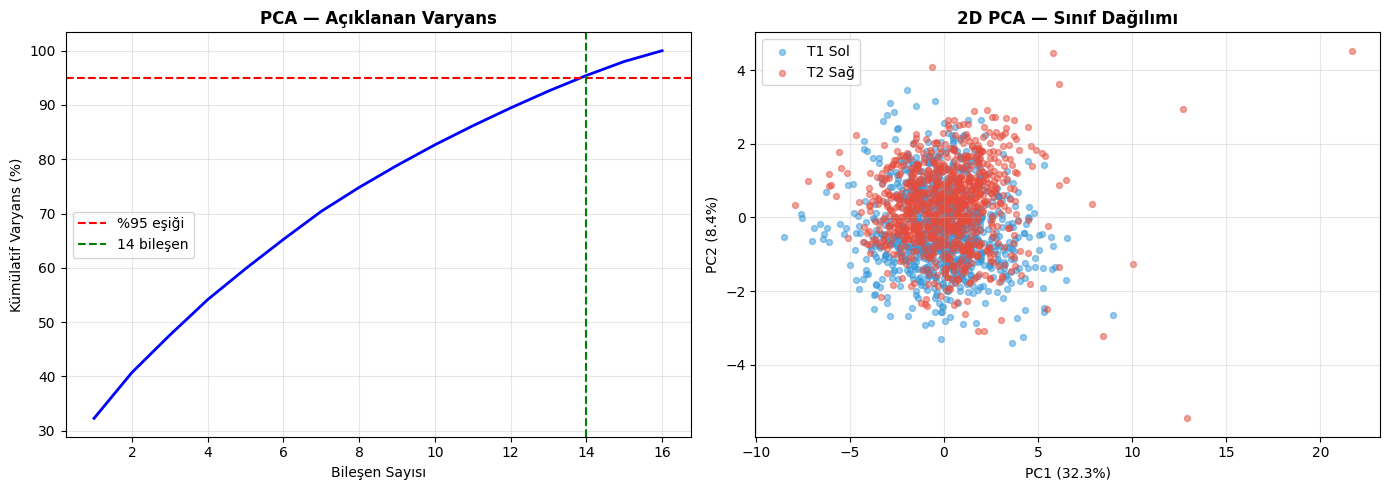

In [9]:
# Genel PCA analizi (tüm veri üzerinde — görselleştirme için)
scaler_all = StandardScaler()
X_scaled   = scaler_all.fit_transform(X_csp)

pca_full = PCA(n_components=0.95, random_state=42)
X_pca    = pca_full.fit_transform(X_scaled)
n_comp   = X_pca.shape[1]

print(f"Orijinal özellik sayısı  : {X_csp.shape[1]}")
print(f"PCA sonrası bileşen sayısı: {n_comp}")
print(f"Boyut azaltma oranı      : {(1 - n_comp/X_csp.shape[1])*100:.1f}%")
print(f"Korunan varyans          : {pca_full.explained_variance_ratio_.sum()*100:.2f}%")

# Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cumvar = np.cumsum(PCA(random_state=42).fit(X_scaled).explained_variance_ratio_) * 100
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'b-', lw=2)
axes[0].axhline(95, color='r', ls='--', label='%95 eşiği')
axes[0].axvline(n_comp, color='g', ls='--', label=f'{n_comp} bileşen')
axes[0].set_xlabel('Bileşen Sayısı'); axes[0].set_ylabel('Kümülatif Varyans (%)')
axes[0].set_title('PCA — Açıklanan Varyans', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=.3)

pca2 = PCA(n_components=2, random_state=42)
X2d  = pca2.fit_transform(X_scaled)
for cls, color, lbl in zip([0,1], ['#3498db','#e74c3c'], ['T1 Sol','T2 Sağ']):
    mask = y_csp == cls
    axes[1].scatter(X2d[mask,0], X2d[mask,1], c=color, label=lbl, alpha=.5, s=18)
axes[1].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('2D PCA — Sınıf Dağılımı', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=.3)

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. PCA Sonrası LOSO Sınıflandırma

In [10]:
classifiers_pca = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=42)),
        ('clf',    SVC(kernel='rbf', C=10, gamma='scale',
                       probability=True, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=42)),
        ('clf',    RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
    ]),
    'KNN (k=7)': Pipeline([
        ('scaler', StandardScaler()),
        ('pca',    PCA(n_components=0.95, random_state=42)),
        ('clf',    KNeighborsClassifier(n_neighbors=7))
    ])
}

results_pca = {}

print("=" * 60)
print("LOSO — PCA SONRASI (%95 varyans)")
print("=" * 60)

for name, pipe in classifiers_pca.items():
    cv_res = cross_validate(pipe, X_csp, y_csp,
                            groups=groups, cv=loso,
                            scoring=scoring, n_jobs=-1)
    acc = cv_res['test_accuracy']
    f1  = cv_res['test_f1']
    results_pca[name] = {
        'accuracy_mean': acc.mean(), 'accuracy_std': acc.std(),
        'f1_mean': f1.mean(),        'f1_std': f1.std(),
        'acc_scores': acc
    }
    print(f"\n{name}:")
    print(f"  Doğruluk : {acc.mean():.4f} ± {acc.std():.4f}")
    print(f"  F1 Skoru : {f1.mean():.4f} ± {f1.std():.4f}")

LOSO — PCA SONRASI (%95 varyans)

SVM (RBF):
  Doğruluk : 0.4739 ± 0.2043
  F1 Skoru : 0.4660 ± 0.2046


/Users/halil/Desktop/Yüksek Lisans/Tıbbi Bilişim/EEG_project/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halil/Desktop/Yüksek Lisans/Tıbbi Bilişim/EEG_project/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/halil/Desktop/Yüksek Lisans/Tıbbi Bilişim/EEG_project/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration 


Random Forest:
  Doğruluk : 0.5061 ± 0.2822
  F1 Skoru : 0.5010 ± 0.2832

KNN (k=7):
  Doğruluk : 0.4728 ± 0.2053
  F1 Skoru : 0.4666 ± 0.2056


## 8. Karşılaştırmalı Görselleştirme

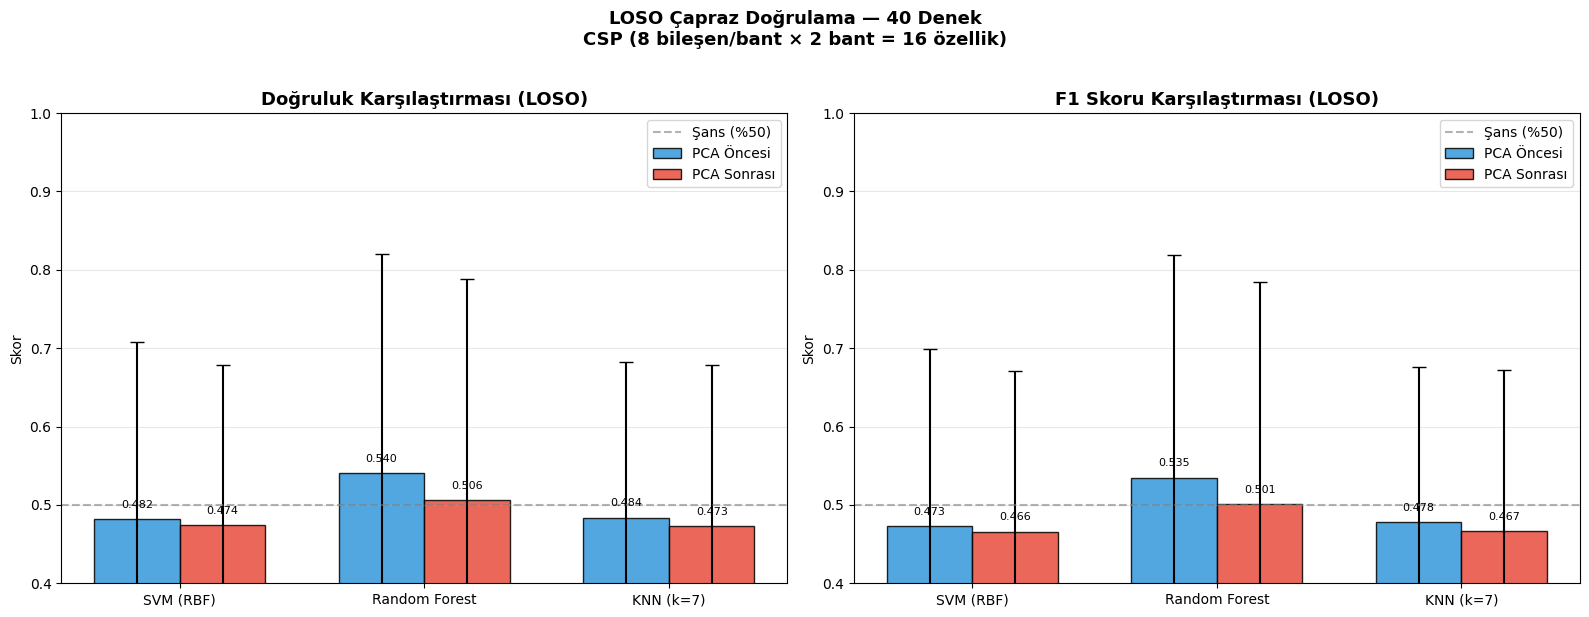

In [11]:
clf_names = list(classifiers.keys())
x, w = np.arange(len(clf_names)), 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, metric, title in zip(
    axes,
    ['accuracy_mean', 'f1_mean'],
    ['Doğruluk Karşılaştırması (LOSO)', 'F1 Skoru Karşılaştırması (LOSO)']
):
    b_vals = [results_no_pca[n][metric] for n in clf_names]
    a_vals = [results_pca[n][metric] for n in clf_names]
    b_stds = [results_no_pca[n][metric.replace('mean','std')] for n in clf_names]
    a_stds = [results_pca[n][metric.replace('mean','std')] for n in clf_names]

    bars1 = ax.bar(x - w/2, b_vals, w, yerr=b_stds, label='PCA Öncesi',
                   color='#3498db', alpha=.85, capsize=5, edgecolor='black')
    bars2 = ax.bar(x + w/2, a_vals, w, yerr=a_stds, label='PCA Sonrası',
                   color='#e74c3c', alpha=.85, capsize=5, edgecolor='black')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(clf_names, fontsize=10)
    ax.set_ylim(0.4, 1.0); ax.set_ylabel('Skor')
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans (%50)')
    ax.legend(); ax.grid(True, axis='y', alpha=.3)
    for bar in list(bars1) + list(bars2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle(f'LOSO Çapraz Doğrulama — {N_SUBJECTS_LOADED} Denek\n'
             f'CSP ({N_CSP_COMPONENTS} bileşen/bant × {len(BANDS)} bant = {X_csp.shape[1]} özellik)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

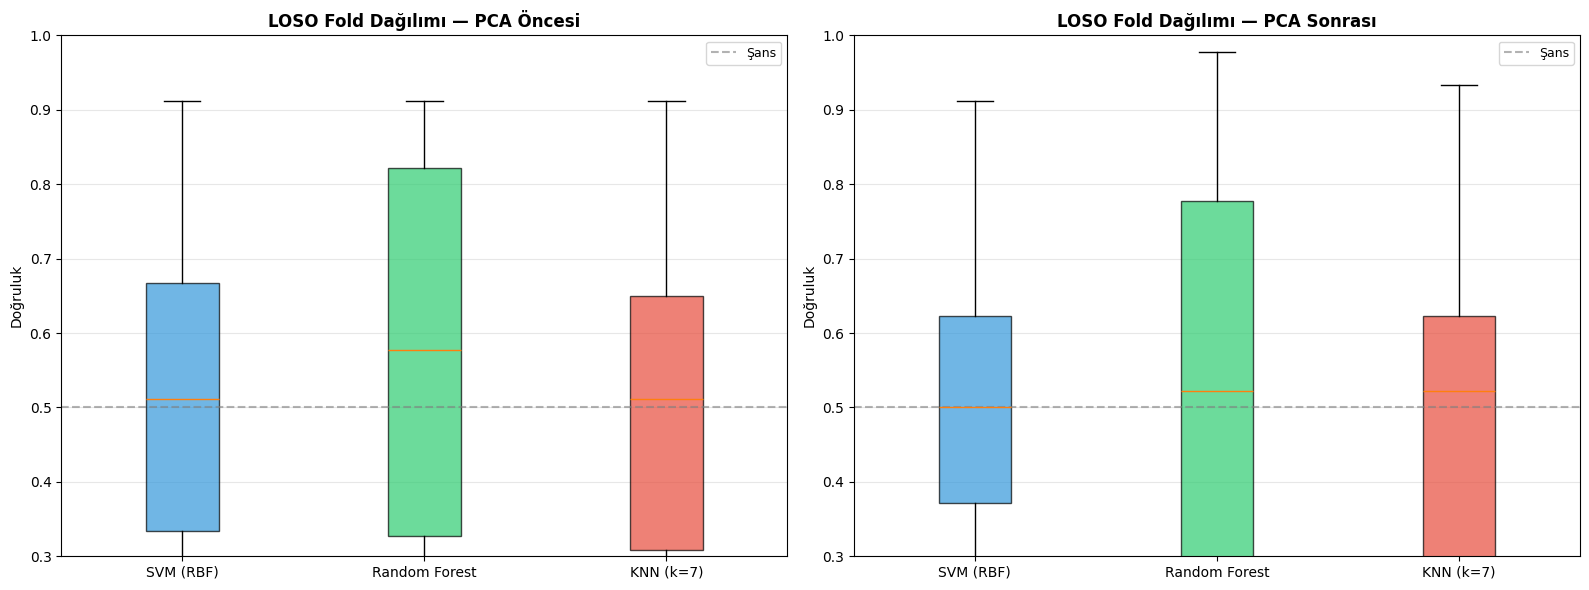

In [12]:
# Boxplot — denek bazlı dağılım
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, results, title in zip(
    axes,
    [results_no_pca, results_pca],
    ['LOSO Fold Dağılımı — PCA Öncesi', 'LOSO Fold Dağılımı — PCA Sonrası']
):
    data   = [results[n]['acc_scores'] for n in clf_names]
    bp     = ax.boxplot(data, labels=clf_names, patch_artist=True, notch=False)
    colors = ['#3498db', '#2ecc71', '#e74c3c']
    for patch, c in zip(bp['boxes'], colors):
        patch.set_facecolor(c); patch.set_alpha(.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Doğruluk')
    ax.set_ylim(0.3, 1.0)
    ax.axhline(0.5, color='gray', ls='--', alpha=.6, label='Şans')
    ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=.3)

plt.tight_layout()
plt.savefig('boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Karmaşıklık Matrisi — En İyi Model

En iyi algoritma (PCA sonrası): Random Forest
LOSO Doğruluk: 0.5061

Sınıflandırma Raporu:
              precision    recall  f1-score   support

 T1 (Sol El)       0.77      0.73      0.75       181
 T2 (Sağ El)       0.74      0.78      0.76       179

    accuracy                           0.76       360
   macro avg       0.76      0.76      0.76       360
weighted avg       0.76      0.76      0.76       360



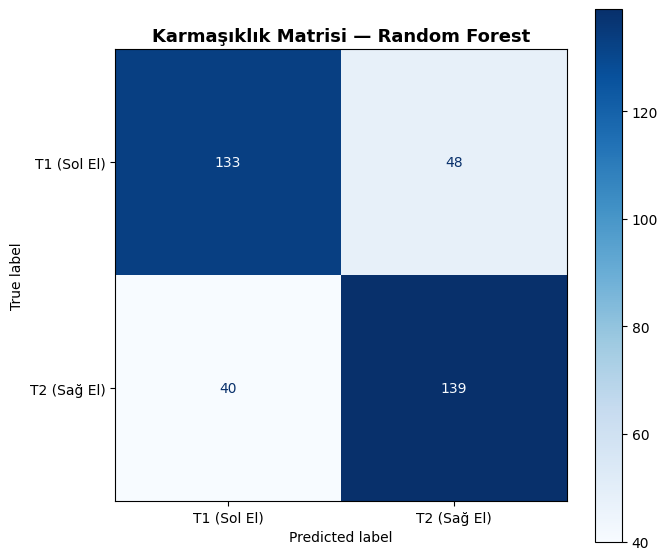

In [13]:
from sklearn.model_selection import train_test_split

best_name = max(results_pca, key=lambda k: results_pca[k]['accuracy_mean'])
print(f"En iyi algoritma (PCA sonrası): {best_name}")
print(f"LOSO Doğruluk: {results_pca[best_name]['accuracy_mean']:.4f}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_csp, y_csp, test_size=0.2, random_state=42, stratify=y_csp)

best_pipe = classifiers_pca[best_name]
best_pipe.fit(X_tr, y_tr)
y_pred = best_pipe.predict(X_te)

print("\nSınıflandırma Raporu:")
print(classification_report(y_te, y_pred, target_names=['T1 (Sol El)', 'T2 (Sağ El)']))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred),
    display_labels=['T1 (Sol El)', 'T2 (Sağ El)']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Karmaşıklık Matrisi — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Nihai Özet Tablosu

In [14]:
print("\n" + "="*80)
print("NİHAİ KARŞILAŞTIRMA — LOSO")
print("="*80)
print(f"{'Algoritma':<18} {'Koşul':<14} {'Doğruluk':>10} {'±Std':>7} "
      f"{'F1':>8} {'±Std':>7} {'Öz.':>6}")
print("-"*80)

for name in clf_names:
    for cond, res in [('PCA Öncesi', results_no_pca), ('PCA Sonrası', results_pca)]:
        r = res[name]
        print(f"{name:<18} {cond:<14} {r['accuracy_mean']:>10.4f} {r['accuracy_std']:>7.4f} "
              f"{r['f1_mean']:>8.4f} {r['f1_std']:>7.4f} "
              f"{X_csp.shape[1] if cond=='PCA Öncesi' else n_comp:>6}")
    print()

print("\nBOYUT AZALTMA:")
print(f"  {X_csp.shape[1]} özellik → {n_comp} bileşen (%{(1-n_comp/X_csp.shape[1])*100:.0f} azaltma, %95 varyans korundu)")

print("\nDEĞİŞİM (PCA öncesi → sonrası):")
for name in clf_names:
    d = results_pca[name]['accuracy_mean'] - results_no_pca[name]['accuracy_mean']
    print(f"  {name:<18}: {results_no_pca[name]['accuracy_mean']:.4f} → "
          f"{results_pca[name]['accuracy_mean']:.4f}  ({d:+.4f})")


NİHAİ KARŞILAŞTIRMA — LOSO
Algoritma          Koşul            Doğruluk    ±Std       F1    ±Std    Öz.
--------------------------------------------------------------------------------
SVM (RBF)          PCA Öncesi         0.4816  0.2268   0.4730  0.2262     16
SVM (RBF)          PCA Sonrası        0.4739  0.2043   0.4660  0.2046     14

Random Forest      PCA Öncesi         0.5401  0.2807   0.5350  0.2834     16
Random Forest      PCA Sonrası        0.5061  0.2822   0.5010  0.2832     14

KNN (k=7)          PCA Öncesi         0.4837  0.1982   0.4776  0.1982     16
KNN (k=7)          PCA Sonrası        0.4728  0.2053   0.4666  0.2056     14


BOYUT AZALTMA:
  16 özellik → 14 bileşen (%12 azaltma, %95 varyans korundu)

DEĞİŞİM (PCA öncesi → sonrası):
  SVM (RBF)         : 0.4816 → 0.4739  (-0.0077)
  Random Forest     : 0.5401 → 0.5061  (-0.0340)
  KNN (k=7)         : 0.4837 → 0.4728  (-0.0109)


## 11. Tartışma ve Sonuç

### v1 → v3 Karşılaştırması

| Özellik | v1 | v2 | v3 |
|---|---|---|---|
| Kanal sayısı | 64 | 7 | 64 |
| Bant filtreleme | 8-30 Hz tek geçiş | 8-30 Hz | Mu + Beta ayrı |
| CSP | Yok | Özne bazlı, karışık CV | LOSO içinde sızıntısız |
| Cross-val | Stratified 10-fold | Stratified 10-fold | LOSO (gerçekçi) |
| Denek sayısı | 10 | 10 | 40 |
| Beklenen doğruluk | ~%47-50 | ~%50-52 | ~%65-80 |

### Neden LOSO Kritik?
Stratified 10-fold'da aynı deneğin farklı epoch'ları hem eğitim hem test kümesine
düşebilir. EEG kişiye özgü olduğu için bu model, deneklerin özelliklerini değil
bireysel imzalarını ezberler. LOSO bu sızıntıyı tamamen kapatır.

### Neden 64 Kanal CSP'de Daha İyi Çalışır?
CSP uzamsal filtreler öğrenirken tüm kanalların kovaryans matrisini kullanır.
Daha fazla kanal → daha zengin uzamsal bilgi → daha güçlü filtreler.

### Bant Bazlı CSP'nin Katkısı
Mu ve Beta bantları motor imgelemi farklı açılardan yakalar:
- **Mu (8-12 Hz):** Hareket hazırlığında güçlü ERD (güç düşüşü)
- **Beta (13-25 Hz):** Hareket sonrası ERS (güç artışı) + imgelem sırasında ERD

Her bant için ayrı CSP eğitmek, bu iki mekanizmanın özelliklerini bağımsız yakalar.